In [1]:
import numpy as np
from Utils import CanonicalUnits, calcKeplerianJacobians, Kepler, GravitationalParameters, X2E, computeNumericalJacobian, OrbitTrasformations
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
%load_ext autoreload 
%autoreload 2

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
def compute_functions(i: float, w: float, Omega: float, 
                    which: Set[str]) -> Dict[str, float]:
    """Compute transformation functions A, B, C, D, F, G"""
    results = {}
    
    if 'A' in which:
        results['A'] = (np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.cos(i)*np.sin(w))
    if 'B' in which:
        results['B'] = (-np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(i)*np.cos(w))
    if 'C' in which:
        results['C'] = (np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.cos(i)*np.sin(w))
    if 'D' in which:
        results['D'] = (-np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(i)*np.cos(w))
    if 'F' in which:
        results['F'] = np.sin(w) * np.sin(i)
    if 'G' in which:
        results['G'] = np.cos(w) * np.sin(i)
    
    return results

def compute_state_vector(E: np.array, mu: float) -> np.array:
    state_vector = spy.conics(E+[0, mu], 0)
    return state_vector

def jacobian_XoE(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> np.array:
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D', 'F', 'G'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    F = functions['F']
    G = functions['G']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_z = state_vector[2]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)
    partial_a_vz = -state_vector[5]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_z, partial_a_vx, partial_a_vy, partial_a_vz]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        drAde*F+drBde*G,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D,
        dvAde*F+dvBde*G
    ])

    #partial i
    partial_i_x = state_vector[2]*np.sin(Omega)
    partial_i_y = -state_vector[2]*np.cos(Omega)
    partial_i_z = -state_vector[0]*np.sin(Omega) + state_vector[1]*np.cos(Omega)

    partial_i_vx = state_vector[5]*np.sin(Omega)
    partial_i_vy = -state_vector[5]*np.cos(Omega)
    partial_i_vz = -state_vector[3]*np.sin(Omega) + state_vector[4]*np.cos(Omega)

    partial_i = [partial_i_x, partial_i_y, partial_i_z, partial_i_vx, partial_i_vy, partial_i_vz]

    #partial Omega
    partial_Omega_x = -state_vector[1]
    partial_Omega_y = state_vector[0]
    partial_Omega_z = 0

    partial_Omega_vx = -state_vector[4]
    partial_Omega_vy = state_vector[3]
    partial_Omega_vz = 0

    partial_Omega = [partial_Omega_x, partial_Omega_y, partial_Omega_z, partial_Omega_vx, partial_Omega_vy, partial_Omega_vz]

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_z = state_vector[0]*np.sin(i)*np.cos(Omega) + state_vector[1]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)
    partial_w_vz = state_vector[3]*np.sin(i)*np.cos(Omega) + state_vector[4]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_z, partial_w_vx, partial_w_vy, partial_w_vz]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_z = (1/n) * state_vector[5]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]
    partial_M_vz = factor * state_vector[2]

    partial_M = [partial_M_x, partial_M_y, partial_M_z, partial_M_vx, partial_M_vy, partial_M_vz]

    J = np.zeros((6,6))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_i
    J[:,3] = partial_Omega
    J[:,4] = partial_w
    J[:,5] = partial_M
    
    return J


In [4]:
a = 0.5
e = 0.1
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,i,w,Omega,M,mu)

Je2c=np.eye(6)
Je2c[0,0]=1/(1-e)
Je2c[0,1]=q/(1-e)**2
Jq=np.matmul(J,Je2c)
Jq

array([[-1.22222222e+00, -1.11111111e+00,  1.25333620e-31,
        -6.73555740e-17,  1.02342668e-15,  8.98241160e-16],
       [ 1.49679053e-16,  1.36071867e-16,  1.02342668e-15,
        -5.50000000e-01, -3.36777870e-17, -2.76933677e-17],
       [ 2.27428151e-15,  1.13744923e-15,  6.16297582e-32,
         0.00000000e+00,  5.50000000e-01,  4.52267017e-01],
       [-1.77391654e-14, -6.07629559e-15,  9.84438316e-16,
         4.92219158e-16,  8.03854889e+00,  7.34458692e+00],
       [ 5.46910176e-16,  7.70646157e-16,  8.03854889e+00,
         1.59652489e-14, -9.84438316e-16, -8.99452486e-16],
       [-8.93172099e+00, -1.25856068e+01,  4.92219158e-16,
         0.00000000e+00, -1.59652489e-14, -1.36666294e-14]])

In [5]:
E = [q, e, i, Omega, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE_comp=computeNumericalJacobian(E2X,E,dX,**args)
JXoE_comp

array([[-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 1.49679053e-16,  1.36072035e-16,  2.05339955e-16,
        -5.49999908e-01, -3.36777814e-17, -2.76933643e-17],
       [-1.36952207e-13, -2.72707654e-13,  0.00000000e+00,
         0.00000000e+00,  5.49999908e-01,  4.52266960e-01],
       [-3.58961694e-12, -1.79880252e-12,  9.84438152e-16,
         4.92219076e-16,  8.03854755e+00,  7.34458628e+00],
       [ 5.46911864e-16,  7.70646442e-16,  8.03854755e+00,
         5.20179705e-15, -9.84438152e-16, -8.99452407e-16],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

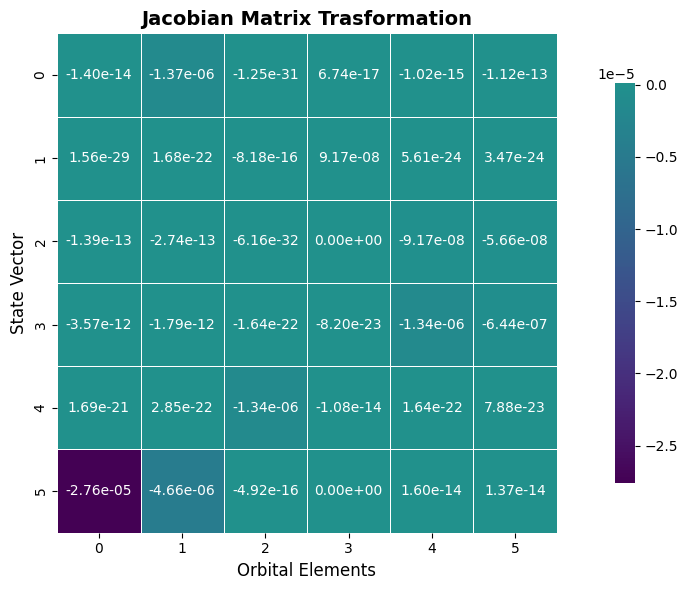

In [6]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(JXoE_comp - Jq, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
def trasformation_E_to_X(a: float, e: float, i: float, Omega: float, w: float, M: float, mu: float) -> tuple[float, float, float, float, float, float]:
    q = a*(1-e)

    state_vec = compute_state_vector([q, e, i, Omega, w, M], mu)
    x = state_vec[0]
    y = state_vec[1]
    z = state_vec[2]
    vx = state_vec[3]
    vy = state_vec[4]
    vz = state_vec[5]

    return x, y, z, vx, vy, vz

def trasformation_X_to_E(x: float, y: float, z: float, vx: float, vy: float, vz: float, mu: float) -> tuple[float, float, float, float, float, float]:

    elements = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    i = elements[2]
    Omega = elements[3]
    w = elements[4]
    M = elements[5]
    a = q/(1-e)

    return a, e, i, Omega, w, M

In [8]:
N = int(1e7)

file_state = f"../datos/random_uniform_elements/state_vector_N{N}.dat"
file_elements = f"../datos/random_uniform_elements/elements_N{N}.dat"

if not os.path.isfile(file_elements) or not os.path.isfile(file_state) or 0:
    print(f"Generating elements")
    a_uniform = np.random.uniform(0, 2, N)
    e_uniform = np.random.uniform(0, 1, N)
    i_uniform = np.random.uniform(0, np.pi, N)
    Omega_uniform = np.random.uniform(0, 2*np.pi, N)
    w_uniform = np.random.uniform(0, 2*np.pi, N)
    M_uniform = np.random.uniform(0, 2*np.pi, N)
    q_uniform = a_uniform*(1-e_uniform)

    elements = np.column_stack((a_uniform, e_uniform, i_uniform, Omega_uniform, w_uniform, M_uniform, q_uniform))

    np.savetxt(file_elements, elements)

    print("Generation state vector")
    state_vectors = np.zeros((N, 6))
    for el in tqdm(range(N)):
        a = a_uniform[el]
        e = e_uniform[el]
        i = i_uniform[el]
        Omega = Omega_uniform[el]
        w = w_uniform[el]
        M = M_uniform[el]

        x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
        state_vectors[el] = np.array([x, y, z, vx, vy, vz])

    np.savetxt(file_state, state_vectors)
else:
    print('data vectors already generated')
    print('Loading files') 
    state_vectors = np.loadtxt(file_state)
    elements = np.loadtxt(file_elements)      

data vectors already generated
Loading files


In [9]:
state_vectors

array([[-4.77841929e-02,  3.04403677e-01, -3.55637276e-01,
        -3.29274820e+00,  1.78783083e+00,  4.37917997e+00],
       [-2.33662550e+00, -7.22989066e-01,  6.50882193e-03,
         1.57937457e+00,  2.62397354e+00, -5.07594618e-02],
       [ 2.11707156e+00,  1.32757077e+00, -1.32365611e+00,
         1.79584607e+00, -1.90879184e+00, -9.07133679e-01],
       ...,
       [-6.99408366e-01, -1.68375332e-01,  1.15337437e+00,
        -5.68761165e-01,  2.46038149e+00, -2.32783011e+00],
       [ 1.03792200e-02, -4.16679606e-01, -2.03339665e-01,
         1.78633899e+00, -3.00112120e+00,  7.10812844e-01],
       [-3.19595996e-01,  2.11265402e-01, -4.49315531e-01,
         7.35102511e+00,  6.08565269e+00, -6.86104809e-01]])

In [10]:
def P_E() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    i_max = np.pi; i_min = 0
    Omega_max = 2*np.pi; Omega_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0

    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(i_max - i_min) * 1/(Omega_max - Omega_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_X(x: float, y: float, z: float, vx: float, vy: float, vz: float) -> float:
    a, e, i, Omega, w, M = trasformation_X_to_E(x, y, z, vx, vy, vz, mu)
    J = jacobian_XoE(a,e,i,Omega,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_E() * abs(det)
    return P

def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = jacobian_XoE(a,e,i,Omega,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape)

In [11]:
def surface_integral_P_X(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()

    # Evaluate P at all points
    Pf = P_X_vectorized(Xf, Yf, Zf, VXf, VYf, VZf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    return integral

In [18]:
# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 1
c_z = 0
v_x = 1.5
v_y = 6
v_z = 0

dxyz = 0.5
dvxyz = 0.5

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')

Theoretical (integral) number of objects in volume: 5.719137300856375
Numerical (count) number of objects inside volume: 1


In [13]:
0.5/2

0.25

In [14]:
(mu/1)**0.5

6.2840227308020005

In [2]:
import pandas as pd

data = pd.read_csv("count_objects.csv")
data.tail(20)


,transformation_type,numerical_count,theoretical_count,objects_generated
130,uniform_aewM,115,117.758252,100000
131,uniform_aewM,1151,1177.582522,1000000
132,uniform_aewM,1196,1177.582522,1000000
133,uniform_aewM,1161,117.758252,1000000
134,uniform_aewM,1170,117.758252,1000000
135,uniform_aewM,1165,117.758252,1000000
136,uniform_aewM,1169,117.758252,1000000
137,uniform_aewM,1158,117.758252,1000000
138,uniform_aewM,1174,117.758252,1000000
139,uniform_aewM,1218,117.758252,1000000


In [16]:
list_count_objects = []
for i in range(10):
    list_count_objects.append({"transformation_type": "uniform_complete", "numerical_count": i, "theoretical_count": i+1, "objects_generated": i+2})
df = pd.concat([data, pd.DataFrame(list_count_objects)], ignore_index=True)
df

,transformation_type,numerical_count,theoretical_count,objects_generated
0,uniform_complete,5,4.938991,100000
1,uniform_complete,6,4.938991,100000
2,uniform_complete,6,4.938991,100000
3,uniform_complete,6,4.938991,100000
4,uniform_complete,6,4.938991,100000
...,...,...,...,...
135,uniform_complete,5,6.000000,7
136,uniform_complete,6,7.000000,8
137,uniform_complete,7,8.000000,9
138,uniform_complete,8,9.000000,10
